In [117]:
# Add all necessary libraries

import pandas as pd
import numpy as np
import regex as re
import matplotlib.pyplot as plt
import seaborn as sns


%pip install pandas openpyxl

Note: you may need to restart the kernel to use updated packages.


In [8]:
# Load data Set
auction_df = pd.read_csv(r'C:\Users\Solen Tadesse\ALX_ML\PORTFOLIO\Compiled_csv_file\compiled.csv')
auction_df.head()

,No,Grade,Price per m2,Advance payment in %,Sub-City,Woreda,Area size in m2,Area code,,Date,Remark
0,1.0,1,"93,460.00",40%,Kolfe Keraniyo,3,214,LDR_KOL_MIX_00013050,Highest Bidder,04--2024,NaN
1,NaN,2,"36,100.00",100%,Kolfe Keraniyo,3,214,LDR_KOL_MIX_00013050,NaN,04--2024,NaN
2,NaN,3,"56,545.00",61%,Kolfe Keraniyo,3,214,LDR_KOL_MIX_00013050,NaN,04--2024,NaN
3,2.0,1,"45,800.00",100%,Kolfe Keraniyo,3,546,LDR_KOL_MIX_00013051,Highest Point,04--2024,NaN
4,NaN,2,"51,999.00",52%,Kolfe Keraniyo,3,546,LDR_KOL_MIX_00013051,NaN,04--2024,NaN


In [11]:
# Are there null values in the dataset?
auction_df.isnull().sum()


No                      3007
Grade                      0
Price per m2               0
Advance payment in %       0
Sub-City                   0
Woreda                     0
Area size in m2            0
Area code                  0
                        3007
Date                       0
Remark                  4564
dtype: int64

In [ ]:
#Drop the 'No' column
auction_df.drop(columns=['No'], inplace=True)


In [13]:
# see top 5 rows of the dataset
auction_df.head()

,Grade,Price per m2,Advance payment in %,Sub-City,Woreda,Area size in m2,Area code,,Date,Remark
0,1,"93,460.00",40%,Kolfe Keraniyo,3,214,LDR_KOL_MIX_00013050,Highest Bidder,04--2024,NaN
1,2,"36,100.00",100%,Kolfe Keraniyo,3,214,LDR_KOL_MIX_00013050,NaN,04--2024,NaN
2,3,"56,545.00",61%,Kolfe Keraniyo,3,214,LDR_KOL_MIX_00013050,NaN,04--2024,NaN
3,1,"45,800.00",100%,Kolfe Keraniyo,3,546,LDR_KOL_MIX_00013051,Highest Point,04--2024,NaN
4,2,"51,999.00",52%,Kolfe Keraniyo,3,546,LDR_KOL_MIX_00013051,NaN,04--2024,NaN


In [17]:
# for every unique element in the'Sub-City' column,replace spaces and hyphens with underscores
auction_df['Sub-City'] = auction_df['Sub-City'].str.replace(' ', '_')
auction_df['Sub-City'] = auction_df['Sub-City'].str.replace('-', '_')

In [18]:
#see top 5 rows of the dataset
auction_df.head()

,Grade,Price per m2,Advance payment in %,Sub-City,Woreda,Area size in m2,Area code,,Date,Remark
0,1,"93,460.00",40%,Kolfe_Keraniyo,3,214,LDR_KOL_MIX_00013050,Highest Bidder,04--2024,NaN
1,2,"36,100.00",100%,Kolfe_Keraniyo,3,214,LDR_KOL_MIX_00013050,NaN,04--2024,NaN
2,3,"56,545.00",61%,Kolfe_Keraniyo,3,214,LDR_KOL_MIX_00013050,NaN,04--2024,NaN
3,1,"45,800.00",100%,Kolfe_Keraniyo,3,546,LDR_KOL_MIX_00013051,Highest Point,04--2024,NaN
4,2,"51,999.00",52%,Kolfe_Keraniyo,3,546,LDR_KOL_MIX_00013051,NaN,04--2024,NaN


In [19]:
# list all unique elements in 'Sub-City' column
auction_df['Sub-City'].unique()

array(['Kolfe_Keraniyo', 'Kirkos', 'Yeka', 'Gullele', 'Bole', 'Lideta',
       'Akaki_Kality', 'Arada', 'Addis_Ketema', 'Nifas_Silk_Lafto',
       'Nifas_Silk_Lafto\xa0', 'Gullele\xa0', 'Bole\xa0', 'Lemi_Kura'],
      dtype=object)

In [30]:
# use a regex pattern to remove non-breaking spaces (represented as \xa0) in the 'Sub-City' column
auction_df['Sub-City'] = auction_df['Sub-City'].str.replace(r'\xa0', '', regex=True)

In [31]:
## list all unique elements in 'Sub-City' column
auction_df['Sub-City'].unique()

array(['Kolfe_Keraniyo', 'Kirkos', 'Yeka', 'Gullele', 'Bole', 'Lideta',
       'Akaki_Kality', 'Arada', 'Addis_Ketema', 'Nifas_Silk_Lafto',
       'Lemi_Kura'], dtype=object)

In [46]:
# first replace '--' with '-'from the 'Date' column
auction_df['Date'] = auction_df['Date'].str.replace('--', '-')  
# convert the 'Date' column to datetime format                  
auction_df['Date'] = pd.to_datetime(auction_df['Date'], format='%m-%Y') 

In [53]:
# observe data types of each column
auction_df.dtypes

Grade                            int64
Price per m2                    object
Advance payment in %            object
Sub-City                        object
Woreda                           int64
Area size in m2                 object
Area code                       object
                                object
Date                    datetime64[ns]
Remark                          object
dtype: object

In [58]:
# clean all characters from 'Price per m2', 'Area size in m2', and 'Advance payment in %' columns and convert them to float 
auction_df[['Price per m2', 'Area size in m2', 'Advance payment in %']] = auction_df[['Price per m2', 'Area size in m2', 'Advance payment in %']].apply(lambda x: x.str.replace(r'[^\d\.]', '', regex=True))
auction_df[['Price per m2', 'Area size in m2', 'Advance payment in %']] = auction_df[['Price per m2', 'Area size in m2', 'Advance payment in %']].astype(float)        

In [59]:
# check the data types again
auction_df.dtypes

Grade                            int64
Price per m2                   float64
Advance payment in %           float64
Sub-City                        object
Woreda                           int64
Area size in m2                float64
Area code                       object
                                object
Date                    datetime64[ns]
Remark                          object
dtype: object

In [60]:
# observe the top 5 rows of the cleaned dataset
auction_df.head()

,Grade,Price per m2,Advance payment in %,Sub-City,Woreda,Area size in m2,Area code,,Date,Remark
0,1,93460.0,40.0,Kolfe_Keraniyo,3,214.0,LDR_KOL_MIX_00013050,Highest Bidder,2024-04-01,NaN
1,2,36100.0,100.0,Kolfe_Keraniyo,3,214.0,LDR_KOL_MIX_00013050,NaN,2024-04-01,NaN
2,3,56545.0,61.0,Kolfe_Keraniyo,3,214.0,LDR_KOL_MIX_00013050,NaN,2024-04-01,NaN
3,1,45800.0,100.0,Kolfe_Keraniyo,3,546.0,LDR_KOL_MIX_00013051,Highest Point,2024-04-01,NaN
4,2,51999.0,52.0,Kolfe_Keraniyo,3,546.0,LDR_KOL_MIX_00013051,NaN,2024-04-01,NaN


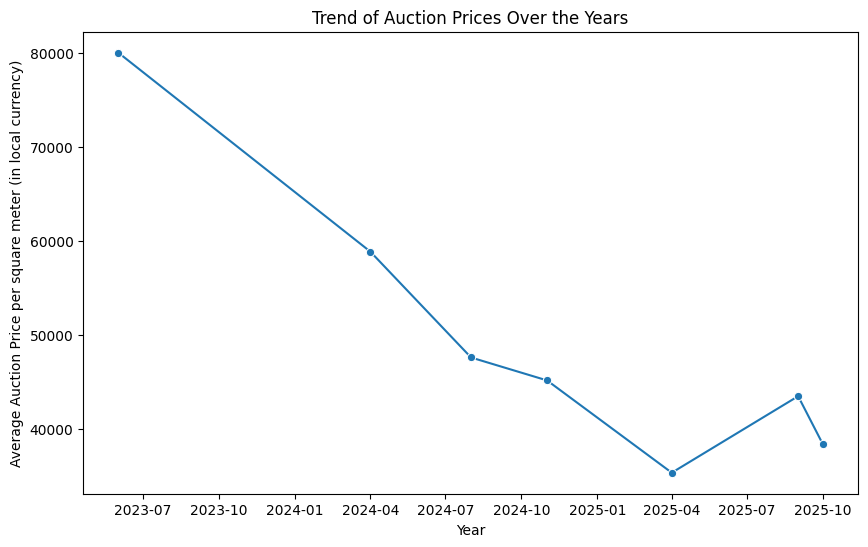

In [67]:
# plot a line chart showing the trend of average auction prices over the years  
plt.figure(figsize=(10, 6))
avg_prices_per_auction = auction_df.groupby('Date')['Price per m2'].mean().reset_index()
sns.lineplot(data=avg_prices_per_auction, x='Date', y='Price per m2', marker='o')
plt.title('Trend of Auction Prices Over the Years')
plt.xlabel('Year')
plt.ylabel('Average Auction Price per square meter (in local currency)') 
plt.show()

C:\Users\Solen Tadesse\AppData\Local\Temp\ipykernel_21472\3136812395.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_prices_by_subcity, x='Sub-City', y='Price per m2', palette='viridis')


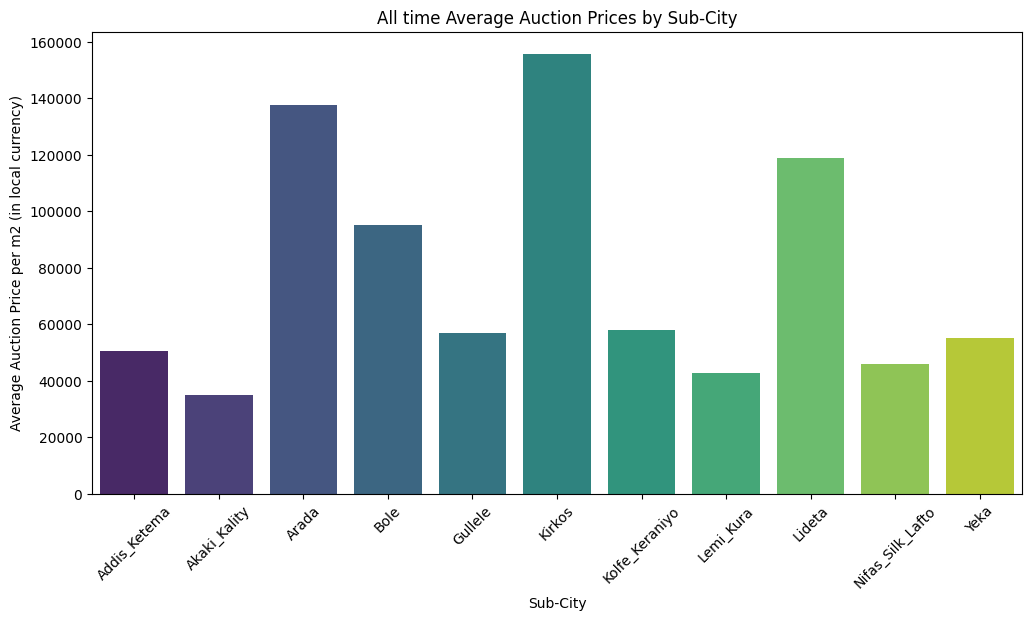

In [ ]:
# Plot a bar chart showing average auction prices by Sub-City 
plt.figure(figsize=(12, 6)) 
avg_prices_by_subcity = auction_df.groupby('Sub-City')['Price per m2'].mean().reset_index()
sns.barplot(data=avg_prices_by_subcity, x='Sub-City', y='Price per m2', palette='viridis')
plt.title('All time Average Auction Prices by Sub-City') 
plt.xlabel('Sub-City')
plt.ylabel('Average Auction Price per m2 (in local currency)')
plt.xticks(rotation=45)
plt.show()


C:\Users\Solen Tadesse\AppData\Local\Temp\ipykernel_21472\272111010.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Sub-City', bbox_to_anchor=(1.05, 1), loc='upper left')


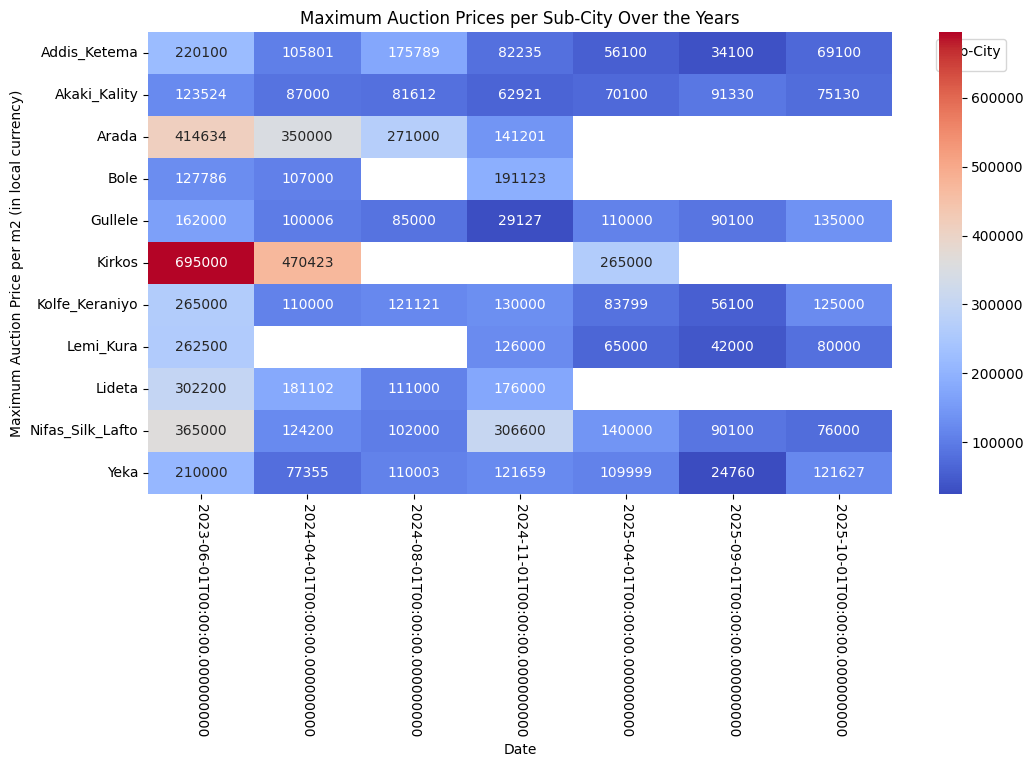

In [85]:
# plot a heatmap showing the maximum auction prices per Sub-City over the years
plt.figure(figsize=(12, 6)) 
max_prices_per_subcity = auction_df.groupby(['Date', 'Sub-City'])['Price per m2'].max().reset_index()
pivot_table = max_prices_per_subcity.pivot(index='Sub-City', columns='Date', values='Price per m2')
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="coolwarm")
plt.title('Maximum Auction Prices per Sub-City Over the Years')
plt.xlabel('Date')
plt.ylabel('Maximum Auction Price per m2 (in local currency)')
plt.xticks(rotation=-90)
plt.legend(title='Sub-City', bbox_to_anchor=(1.05, 1), loc='upper left')


C:\Users\Solen Tadesse\AppData\Local\Temp\ipykernel_21472\1395335866.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title =f'Total Area Auctioned to Date: {total_area_auctioned_to_date} m2')


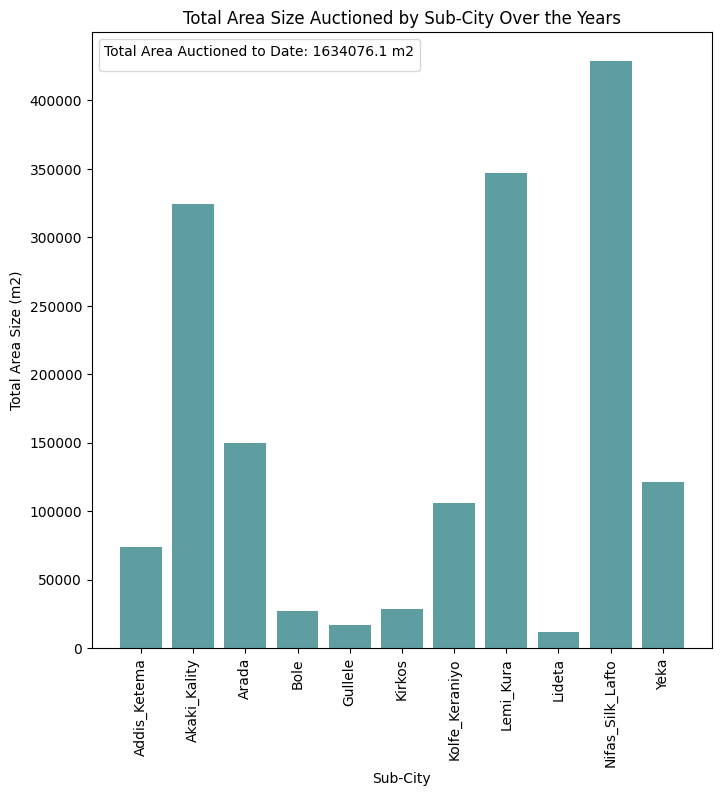

In [126]:
# plot a bar chart showing the total area size auctioned by Sub-City over the years
for area in auction_df['Area size in m2']:
    area_size_by_subcity = auction_df.groupby('Sub-City')['Area size in m2'].sum()  
total_area_auctioned_to_date = area_size_by_subcity.sum()
plt.figure(figsize=(8, 8))
plt.bar(area_size_by_subcity.index, area_size_by_subcity.values, color='cadetblue')
plt.title('Total Area Size Auctioned by Sub-City Over the Years')
plt.xlabel('Sub-City')
plt.ylabel('Total Area Size (m2)')
plt.xticks(rotation=90)
plt.legend(title =f'Total Area Auctioned to Date: {total_area_auctioned_to_date} m2')
plt.show()

In [119]:
total_area = auction_df['Area size in m2'].sum()
print(total_area)

1634076.1
